# A small SMILES VAE: can it generate valid molecules?

This notebook is the narrated entry point for the project. It works through one
question end to end.

**Question.** Can a small character-level GRU variational autoencoder, trained
briefly on a few hundred molecules on a CPU, generate valid SMILES strings, and
does its latent space organize molecules by chemistry?

**Method.** Tokenize SMILES per character, encode to a Gaussian latent, decode
autoregressively, and train the evidence lower bound with KL annealing. Then
sample from the prior and score validity, uniqueness, and novelty with RDKit, and
draw the latent-space map.

The full derivation is in `docs/method.md`. Here we foreground the result, and we
are honest that the validity number is modest.

In [1]:
import matplotlib.pyplot as plt

from molgen import (
    SmilesTokenizer, SmilesDataset, SmilesVAE, Trainer,
    generation_metrics, load_smiles, set_seed,
    latent_means, pca_project, compute_properties,
)

set_seed(0)
smiles = load_smiles("../data/sample_smiles.txt")
tok = SmilesTokenizer().build(smiles)
dataset = SmilesDataset(smiles, tok)
print("training molecules:", len(smiles), "| vocab size:", len(tok))
print("example:", smiles[0])

training molecules: 400 | vocab size: 31
example: Brc1cnc(NCc2ccccc2)nc1Nc1cc(C2CC2)[nH]n1


## The objective and KL annealing

The model maximizes the evidence lower bound (ELBO):

$$\log p_\theta(x) \ge \mathbb{E}_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)] - \mathrm{KL}\big(q_\phi(z\mid x)\,\|\,p(z)\big).$$

The first term is reconstruction (per-character cross entropy), the second pulls
the posterior toward a standard Gaussian prior. For a unit-variance prior the KL
has a closed form,

$$\mathrm{KL} = -\tfrac{1}{2}\sum_j\big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\big),$$

which is one line in `SmilesVAE.loss`.

A strong decoder can lower the loss by driving the KL to zero and ignoring the
latent, a failure called posterior collapse. **KL annealing** ramps the KL weight
`beta` from near zero up to a small target over the first epochs, so the model
first learns to use the latent and only then regularizes it. Watch `beta` climb in
the training log below.

In [2]:
model = SmilesVAE(len(tok), embed_dim=48, hidden_dim=128, latent_dim=32, pad_id=tok.pad_id)
trainer = Trainer(model, pad_id=tok.pad_id, lr=1e-3, max_beta=0.008, kl_anneal_epochs=20)
trainer.fit(dataset, epochs=80, batch_size=64, verbose=False)

for e in [0, 4, 9, 19, 39, 79]:
    h = trainer.history
    print(f"epoch {e+1:3d}  recon={h['recon'][e]:.3f}  kl={h['kl'][e]:.4f}  "
          f"beta={trainer._beta(e):.3f}")

epoch   1  recon=3.231  kl=0.1910  beta=0.000
epoch   5  recon=2.084  kl=4.4331  beta=0.002
epoch  10  recon=1.745  kl=1.3670  beta=0.004
epoch  20  recon=1.361  kl=0.2103  beta=0.008
epoch  40  recon=1.042  kl=0.0074  beta=0.008
epoch  80  recon=0.788  kl=0.0652  beta=0.008


## Sample from the prior and score

Draw latent codes from the standard Gaussian prior, decode them, and measure
validity (does RDKit parse it), uniqueness (distinct valid molecules), and novelty
(valid molecules not in the training set). Nothing forces the decoder to emit valid
SMILES, so validity is an emergent measure of how well it learned the grammar.

In [3]:
gen_ids = model.generate(500, tok.sos_id, tok.eos_id, temperature=0.9)
gen = [tok.decode(ids) for ids in gen_ids]
metrics = generation_metrics(gen, smiles)
print({k: round(v, 3) for k, v in metrics.items() if k != "n_generated"})

from molgen.metrics import canonical
valid = [c for c in (canonical(s) for s in gen) if c]
print("\nexample valid generations:")
for s in valid[:6]:
    print("  ", s)

{'validity': 0.15, 'uniqueness': 0.987, 'novelty': 1.0}

example valid generations:
   COc1ccc2ccc(S(=O)O)nc2c1
   CS(=O)c1ccc(OCc2ccccc2)cc1
   Cc1ccccc1
   O=C1CCCc2ccccc2N1
   CC1=C(N)N=C(N)N(CCCCCNc2ccccc2)N1
   CC1=CC=CC1=O


This 80-epoch run reproduces the committed configuration, so its numbers land
close to `results/metrics.json` (they differ a little because prior sampling is
stochastic and this run draws 500 molecules rather than 1000). Validity is modest,
around 0.1 to 0.15, while uniqueness and novelty are high. The valid samples are
drug-like.

## The latent-space map

Encode every training molecule to its posterior mean, project the means to two
dimensions with PCA, and color each point by Crippen logP. This is the hero
figure. If the latent had fully collapsed the cloud would be a structureless blob;
instead its main axis tracks molecular size, with logP following more weakly. The
organization is partial and is shown at that honest resolution.

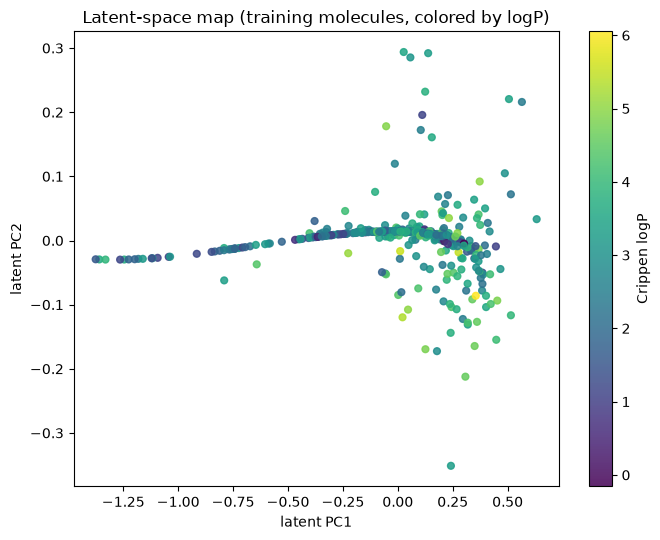

In [4]:
mu = latent_means(model, smiles, tok)
coords = pca_project(mu, 2)
logp = compute_properties(smiles, "logp")

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=logp, cmap="viridis", s=24, alpha=0.85)
fig.colorbar(sc, ax=ax, label="Crippen logP")
ax.set_xlabel("latent PC1"); ax.set_ylabel("latent PC2")
ax.set_title("Latent-space map (training molecules, colored by logP)")
plt.tight_layout(); plt.show()

## Findings

- A 0.15 M parameter character VAE trained briefly on 400 molecules reaches a
  validity around 0.1 to 0.15. Roughly one sampled string in seven to ten is a
  parseable molecule.
- Uniqueness and novelty are near their ceilings, which rules out memorization but
  is not itself the hard part.
- The latent space is lightly used, not collapsed, and organizes molecules partly
  by size and logP.

This is a study and a portfolio piece, not a production generator. See
`model_card.md` for the full, honest account and `docs/method.md` for the math.